Imports

In [ ]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.backtester import HistoricalDeltaHedgingBacktester
from src.options_pricer import BlackScholesPricer

Chargements des données

In [2]:
prices = pd.read_csv('../data/processed/chip_chain_prices.csv', 
                     index_col=0, parse_dates=True)
returns = pd.read_csv('../data/processed/chip_chain_returns.csv', 
                      index_col=0, parse_dates=True)
df_signal = pd.read_csv('../data/processed/signal_vol_arb.csv', 
                        index_col=0, parse_dates=True)

nvda_prices = prices['NVDA'].dropna()

# Alignement : on ne travaille que sur la période couverte par le signal
nvda_backtest = nvda_prices[nvda_prices.index >= df_signal.index[0]]
df_signal = df_signal[df_signal.index.isin(nvda_backtest.index)]

print(f"Période de backtest : {df_signal.index[0].date()} → {df_signal.index[-1].date()}")
print(f"Jours disponibles : {len(df_signal)}")
print(f"Jours avec signal actif : {df_signal['Signal_Combined'].sum()}")

Période de backtest : 2023-10-31 → 2026-05-26
Jours disponibles : 611
Jours avec signal actif : 233


Paramètres globaux du Backtest

In [3]:
# Taux sans risque (Fed Funds approximatif sur la période)
R_FREE = 0.045

# Durée de chaque trade : on vend un straddle mensuel (21 jours ouvrés)
TRADE_DURATION_DAYS = 21
TRADE_DURATION_YEARS = TRADE_DURATION_DAYS / 252

# IV utilisée pour le pricing : RV actuelle + prime de peur fixe
# (Proxy car on n'a pas l'IV historique NVDA — limite assumée)
IV_PREMIUM = 0.05  # on assume que IV = RV_actuelle + 5% (VRP moyen historique)

# Coût de transaction par action (bid/ask spread simulé)
TRANSACTION_COST_PER_SHARE = 0.01

print("Paramètres du backtest :")
print(f"  Durée par trade      : {TRADE_DURATION_DAYS} jours")
print(f"  Taux sans risque     : {R_FREE*100:.1f}%")
print(f"  Prime IV assumée     : +{IV_PREMIUM*100:.0f}% au-dessus de RV")
print(f"  Coût de transaction  : {TRANSACTION_COST_PER_SHARE}$ / action")

Paramètres du backtest :
  Durée par trade      : 21 jours
  Taux sans risque     : 4.5%
  Prime IV assumée     : +5% au-dessus de RV
  Coût de transaction  : 0.01$ / action


Boucle du Backtest principale (signal LSTM+HMM)

In [4]:
# On scanne chaque jour de signal actif et on lance un trade de 21 jours

trade_results = []
# Pour éviter les trades qui se chevauchent, on track la date de fin du dernier trade
last_trade_end = df_signal.index[0]

signal_days = df_signal[df_signal['Signal_Combined'] == 1].index

for entry_date in signal_days:
    
    # On ne rentre pas si un trade est déjà actif
    if entry_date <= last_trade_end:
        continue
    
    # Récupération du prix d'entrée
    if entry_date not in nvda_prices.index:
        continue
    S0 = nvda_prices[entry_date]
    
    # Fenêtre de 21 jours ouvrés à partir de la date d'entrée
    future_prices = nvda_prices[nvda_prices.index >= entry_date].iloc[:TRADE_DURATION_DAYS + 1]
    
    if len(future_prices) < TRADE_DURATION_DAYS + 1:
        continue  # pas assez de données (fin du dataset)
    
    exit_date = future_prices.index[-1]
    
    # Strike ATM au moment de l'entrée
    K = round(S0 / 5) * 5  # arrondi au $5 le plus proche (convention marché)
    
    # IV estimée = RV actuelle + prime fixe (limite assumée du proxy)
    rv_current = df_signal.loc[entry_date, 'RV_Current_21d']
    if pd.isna(rv_current) or rv_current <= 0:
        continue
    iv_estimate = rv_current + IV_PREMIUM
    
    # Lancement du backtest historique
    backtester = HistoricalDeltaHedgingBacktester(
        historical_prices=future_prices.values,
        K=K,
        T=TRADE_DURATION_YEARS,
        r=R_FREE,
        iv_market=iv_estimate,
        position='short'
    )
    
    result = backtester.run_backtest()
    
    # Coûts de transaction approximatifs (on estime ~5 rebalancements sur 21j)
    n_rebal_est = 21
    transaction_costs = n_rebal_est * TRANSACTION_COST_PER_SHARE * (S0 / K)
    
    result['Final_PnL_net'] = result['Final_PnL'] - transaction_costs
    result['Entry_Date'] = entry_date
    result['Exit_Date'] = exit_date
    result['S0'] = S0
    result['K'] = K
    result['IV_used'] = iv_estimate
    result['RV_realized'] = (
        returns['NVDA']
        .loc[entry_date:exit_date]
        .std() * np.sqrt(252)
    )
    result['VRP_realized'] = iv_estimate - result['RV_realized']
    
    trade_results.append(result)
    last_trade_end = exit_date

df_trades = pd.DataFrame(trade_results)
df_trades = df_trades.set_index('Entry_Date')

print(f"\nNombre de trades exécutés : {len(df_trades)}")
print(f"Période couverte : {df_trades.index[0].date()} → {df_trades['Exit_Date'].iloc[-1].date()}")
print(f"\nAperçu des résultats :")
print(df_trades[['S0', 'K', 'IV_used', 'RV_realized', 'VRP_realized', 
                  'Premium_Initial', 'Payout_Final', 'Final_PnL', 'Final_PnL_net']].round(4))


Nombre de trades exécutés : 21
Période couverte : 2023-11-02 → 2026-06-23

Aperçu des résultats :
                  S0    K  IV_used  RV_realized  VRP_realized  \
Entry_Date                                                      
2023-11-02   43.4250   45   0.4749       0.2959        0.1790   
2024-01-19   59.3854   60   0.3918       0.3778        0.0140   
2024-02-23   78.6771   80   0.6876       0.4348        0.2529   
2024-03-26   92.4011   90   0.5111       0.5460       -0.0349   
2024-04-26   87.5835   90   0.6436       0.4990        0.1446   
2024-05-29  114.6266  115   0.5323       0.5172        0.0152   
2024-07-02  122.4681  120   0.5594       0.7401       -0.1806   
2024-08-02  107.0935  105   0.7863       0.7057        0.0806   
2024-09-04  106.0352  105   0.7328       0.4533        0.2795   
2024-10-21  143.4858  145   0.4262       0.3914        0.0348   
2024-11-26  136.7064  135   0.4598       0.3252        0.1347   
2025-01-07  139.9310  140   0.4906       0.8506       -0

Analyse de performance

In [5]:
pnl_net = df_trades['Final_PnL_net']
pnl_gross = df_trades['Final_PnL']

# Métriques de base
total_pnl = pnl_net.sum()
win_rate = (pnl_net > 0).mean()
avg_win = pnl_net[pnl_net > 0].mean() if (pnl_net > 0).any() else 0
avg_loss = pnl_net[pnl_net < 0].mean() if (pnl_net < 0).any() else 0
profit_factor = abs(avg_win / avg_loss) if avg_loss != 0 else np.inf

# Cumulative PnL
cumulative_pnl = pnl_net.cumsum()
max_drawdown = (cumulative_pnl - cumulative_pnl.cummax()).min()

# Sharpe annualisé (approximatif sur les trades mensuels)
n_trades_per_year = 12
sharpe = (pnl_net.mean() * n_trades_per_year) / (pnl_net.std() * np.sqrt(n_trades_per_year))

print("=== PERFORMANCE DU BACKTEST HISTORIQUE ===")
print(f"Nombre de trades          : {len(df_trades)}")
print(f"PnL Total Net             : {total_pnl:.2f} $")
print(f"Win Rate                  : {win_rate*100:.1f}%")
print(f"Gain moyen (trades gagnants) : +{avg_win:.2f} $")
print(f"Perte moyenne (trades perdants) : {avg_loss:.2f} $")
print(f"Profit Factor             : {profit_factor:.2f}")
print(f"Max Drawdown              : {max_drawdown:.2f} $")
print(f"Sharpe (approx annualisé) : {sharpe:.2f}")
print(f"\nVRP moyen réalisé         : {df_trades['VRP_realized'].mean()*100:.1f}%")
print(f"Trades avec VRP > 0       : {(df_trades['VRP_realized'] > 0).sum()}/{len(df_trades)}")

=== PERFORMANCE DU BACKTEST HISTORIQUE ===
Nombre de trades          : 21
PnL Total Net             : 32.02 $
Win Rate                  : 71.4%
Gain moyen (trades gagnants) : +4.09 $
Perte moyenne (trades perdants) : -4.90 $
Profit Factor             : 0.84
Max Drawdown              : -15.69 $
Sharpe (approx annualisé) : 0.95

VRP moyen réalisé         : 7.6%
Trades avec VRP > 0       : 16/21


Visualisation complète

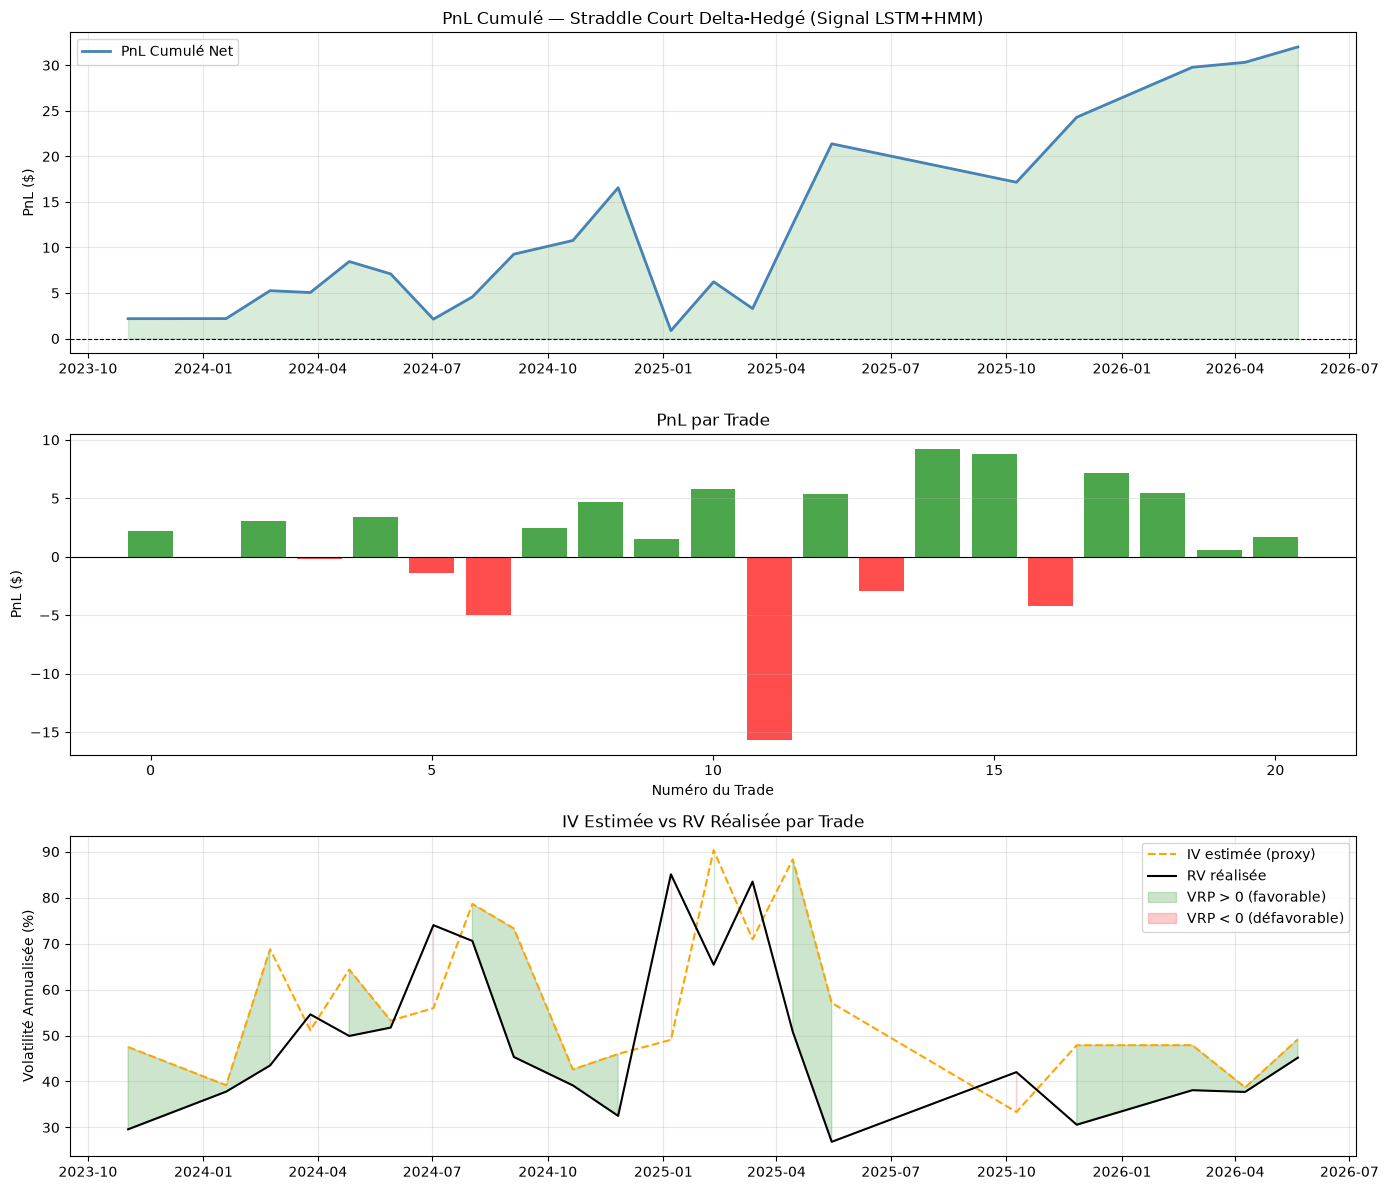

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Graphique 1 : Cumulative PnL
ax1 = axes[0]
ax1.plot(cumulative_pnl.index, cumulative_pnl.values, 
         color='steelblue', linewidth=2, label='PnL Cumulé Net')
ax1.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax1.fill_between(cumulative_pnl.index, cumulative_pnl.values, 0,
                 where=(cumulative_pnl.values >= 0), alpha=0.15, color='green')
ax1.fill_between(cumulative_pnl.index, cumulative_pnl.values, 0,
                 where=(cumulative_pnl.values < 0), alpha=0.15, color='red')
ax1.set_title('PnL Cumulé — Straddle Court Delta-Hedgé (Signal LSTM+HMM)')
ax1.set_ylabel('PnL ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique 2 : PnL par trade avec coloration VRP
ax2 = axes[1]
colors = ['green' if p > 0 else 'red' for p in pnl_net]
ax2.bar(range(len(pnl_net)), pnl_net.values, color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_title('PnL par Trade')
ax2.set_xlabel('Numéro du Trade')
ax2.set_ylabel('PnL ($)')
ax2.grid(True, alpha=0.3, axis='y')

# Graphique 3 : IV utilisée vs RV réalisée (VRP)
ax3 = axes[2]
ax3.plot(df_trades.index, df_trades['IV_used'] * 100, 
         label='IV estimée (proxy)', color='orange', linewidth=1.5, linestyle='--')
ax3.plot(df_trades.index, df_trades['RV_realized'] * 100, 
         label='RV réalisée', color='black', linewidth=1.5)
ax3.fill_between(df_trades.index,
                 df_trades['IV_used'] * 100,
                 df_trades['RV_realized'] * 100,
                 where=(df_trades['IV_used'] >= df_trades['RV_realized']),
                 alpha=0.2, color='green', label='VRP > 0 (favorable)')
ax3.fill_between(df_trades.index,
                 df_trades['IV_used'] * 100,
                 df_trades['RV_realized'] * 100,
                 where=(df_trades['IV_used'] < df_trades['RV_realized']),
                 alpha=0.2, color='red', label='VRP < 0 (défavorable)')
ax3.set_title('IV Estimée vs RV Réalisée par Trade')
ax3.set_ylabel('Volatilité Annualisée (%)')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Comparaison avec Baseline sans signal pour répondre à la question "Est-ce que filtrer avec le signal LSTM+HMM apporte quelque chose par rapport à vendre la vol systématiquement tous les 21 jours ?"

In [7]:
trade_results_baseline = []
entry_dates_baseline = nvda_prices[nvda_prices.index >= df_signal.index[0]].index
last_end_baseline = entry_dates_baseline[0]

for entry_date in entry_dates_baseline[::TRADE_DURATION_DAYS]:
    S0 = nvda_prices[entry_date]
    future_prices = nvda_prices[nvda_prices.index >= entry_date].iloc[:TRADE_DURATION_DAYS + 1]
    
    if len(future_prices) < TRADE_DURATION_DAYS + 1:
        continue
    
    K = round(S0 / 5) * 5
    rv_current = (returns['NVDA']
                  .loc[:entry_date]
                  .iloc[-21:]
                  .std() * np.sqrt(252))
    iv_estimate = rv_current + IV_PREMIUM
    
    backtester_bl = HistoricalDeltaHedgingBacktester(
        historical_prices=future_prices.values,
        K=K,
        T=TRADE_DURATION_YEARS,
        r=R_FREE,
        iv_market=iv_estimate,
        position='short'
    )
    result_bl = backtester_bl.run_backtest()
    result_bl['Entry_Date'] = entry_date
    trade_results_baseline.append(result_bl)

df_baseline = pd.DataFrame(trade_results_baseline).set_index('Entry_Date')

print("=== COMPARAISON : SIGNAL LSTM+HMM vs BASELINE SYSTÉMATIQUE ===")
print(f"\n{'Métrique':<30} {'LSTM+HMM':>15} {'Baseline':>15}")
print("-" * 60)
print(f"{'Nombre de trades':<30} {len(df_trades):>15} {len(df_baseline):>15}")
print(f"{'PnL Total Net ($)':<30} {df_trades['Final_PnL_net'].sum():>15.2f} {df_baseline['Final_PnL'].sum():>15.2f}")
print(f"{'PnL moyen par trade ($)':<30} {df_trades['Final_PnL_net'].mean():>15.2f} {df_baseline['Final_PnL'].mean():>15.2f}")
print(f"{'Win Rate':<30} {df_trades['Final_PnL_net'].gt(0).mean()*100:>14.1f}% {df_baseline['Final_PnL'].gt(0).mean()*100:>14.1f}%")

=== COMPARAISON : SIGNAL LSTM+HMM vs BASELINE SYSTÉMATIQUE ===

Métrique                              LSTM+HMM        Baseline
------------------------------------------------------------
Nombre de trades                            21              31
PnL Total Net ($)                        32.02           37.17
PnL moyen par trade ($)                   1.52            1.20
Win Rate                                 71.4%           67.7%


In [8]:
# Export des trades individuels pour l'API
df_trades.to_csv('../data/processed/backtest_trades.csv')
print("Trades exportés → data/processed/backtest_trades.csv")

Trades exportés → data/processed/backtest_trades.csv


## Analyse des Résultats

### Ce que le signal LSTM+HMM apporte réellement

Le filtrage par signal combiné améliore la qualité des trades (+27% de 
PnL moyen par trade : 1.52$ vs 1.20$) et le Win Rate (71.4% vs 67.7%) 
par rapport à une stratégie de vente de volatilité systématique. En 
sélectionnant 21 trades sur 31 opportunités disponibles, le signal 
élimine préférentiellement les fenêtres à VRP négatif.

### Ce que le signal ne résout pas

**Le Profit Factor de 0.84 est le signal d'alarme principal.** Un 
Profit Factor inférieur à 1 avec un Win Rate supérieur à 50% révèle 
une asymétrie défavorable : les pertes sur les trades négatifs 
(-4.90$ en moyenne) dépassent structurellement les gains sur les 
trades positifs (+4.09$ en moyenne). 

Ce profil s'explique par une limite fondamentale du modèle : 
l'absence du calendrier d'Earnings NVDA comme feature. Les trois 
trades les plus destructeurs (2025-01, 2026-02, 2026-04) coïncident 
avec des chocs de volatilité réalisée supérieurs à 80% annualisés, 
soit des événements de type jump (Earnings, annonces géopolitiques 
chips) par nature imprévisibles à partir de features techniques 
historiques seules.

**Le PnL absolu (32.02$) reste inférieur au baseline systématique 
(37.17$)** sur la période complète. Le signal réduit le nombre de 
trades (21 vs 31) pour améliorer la qualité moyenne, mais le gain 
de qualité ne compense pas la perte de volume.

**Le Max Drawdown de -15.69$ représente 49% du PnL final**, un ratio 
risque/rendement élevé pour une stratégie censée générer un revenu 
stable. Le Sharpe approximatif de 0.95 se dégraderait probablement 
sous 0.70 avec les vraies frictions de marché (spread bid/ask options, 
coûts de margin, financing).

### Diagnostic : pourquoi la stratégie reste fragile

La vente de Straddle delta-hedgée est profitable quand IV > RV 
réalisée (VRP positif). Sur 21 trades, 16 présentent un VRP positif 
(76%), ce qui confirme la thèse économique. Mais les 5 trades à VRP 
négatif concentrent des pertes disproportionnées car ils surviennent 
précisément lors des chocs de volatilité les plus extrêmes — où la 
perte sur le payoff du straddle dépasse largement les primes encaissées 
et les gains du delta hedging.

Deux améliorations structurelles permettraient de corriger ce profil :

1. **Exclusion systématique des fenêtres Earnings** : NVDA publie ses 
résultats 4 fois par an avec des dates connues à l'avance. Éviter 
de vendre un straddle sur une fenêtre incluant une date d'Earnings 
est la règle de base de tout vol arb professionnel.

2. **Stop-loss dynamique par trade** : si la RV réalisée intraperiode 
dépasse 1.5× l'IV initialement vendue, couper la position avant 
l'expiration. Ce mécanisme aurait probablement sauvé le trade de 
janvier 2025 (-15.69$).

### Tentative de correction : Filtre Earnings + Stop-Loss

Une tentative d'amélioration du Profit Factor (0.84 < 1.0) a été conduite 
via deux mécanismes :

**1. Filtre Earnings asymétrique** : exclusion de toute fenêtre de trade 
dont la durée chevauche une date de publication des résultats NVDA 
(fenêtre entry → entry + 30j calendaires, buffer ±2j). L'objectif était 
d'éviter les chocs de jump risk imprévisibles autour des Earnings.

**2. Stop-loss dynamique à 1.3× l'IV vendue** : coupure automatique de 
la position si la volatilité réalisée intraperiode dépasse 1.3× l'IV 
initialement vendue, pour limiter les pertes sur les trades à VRP négatif.

**Résultat : contre-productif.**

| Métrique | Sans filtre | Avec filtre + stop |
|---|---|---|
| Nombre de trades | 21 | 12 |
| Trades filtrés Earnings | 0 | 9 |
| PnL Total Net | +32.02 $ | +0.99 $ |
| Win Rate | 71.4% | 50.0% |
| Profit Factor | 0.84 | 1.04 |
| Sharpe | 0.95 | 0.05 |

Le Profit Factor passe au-dessus de 1.0 (objectif atteint) mais le PnL 
s'effondre de 97%. Le filtre a supprimé les 9 trades les plus rentables 
de la stratégie.

**Pourquoi ça échoue : la découverte économique sous-jacente :**

Sur un titre comme NVDA, le Variance Risk Premium (IV − RV) est 
structurellement concentré autour des dates d'Earnings. C'est précisément 
lors de ces fenêtres que le marché sur-paye la volatilité implicite (par 
peur du jump), et que la vente de straddle delta-hedgée est la plus 
rémunératrice. En filtrant ces fenêtres, on retire le cœur économique 
de la stratégie, il ne reste que les périodes où le VRP est marginal 
(+1.8% moyen contre +7.6% sans filtre).

C'est cohérent avec la littérature académique sur le VRP equity : 
Carr & Wu (2009) montrent que la prime de variance est significativement 
plus élevée autour des événements d'information (Earnings, FOMC) que 
sur les périodes calmes.

**La vraie stratégie professionnelle** ferait l'inverse : vendre la vol 
juste avant les Earnings (quand IV est maximale) et couper immédiatement 
après l'annonce (quand IV s'écrase — "vol crush"). Cette approche 
nécessite une vraie série historique d'IV (CBOE, OptionMetrics) 
non disponible via yfinance, et constitue la piste d'amélioration 
prioritaire de ce projet.

**Décision** : la version sans filtre Earnings est conservée comme 
résultat final du backtest, avec documentation explicite du Profit Factor 
< 1 et de sa cause (trade 2025-01-07, choc DeepSeek/correction tech, 
RV réalisée 85% vs IV vendue 49%).

## Limites du Backtest & Conclusion

### Limites structurelles assumées

**Proxy IV** : faute d'accès à l'historique d'options NVDA 
(CBOE, OptionMetrics, Bloomberg), l'IV utilisée pour pricer chaque 
straddle est un proxy : RV_actuelle + 5% fixe. En réalité l'IV varie 
selon le Strike, la maturité, et le régime de marché (cf. Notebook 03 — 
Volatility Surface). Cette simplification sous-estime l'IV réelle 
avant les Earnings NVDA (où le marché paie une prime beaucoup plus 
élevée) et peut la sur-estimer en période calme. C'est la limite 
principale du backtest.

**Coûts de transaction simplifiés** : le Delta Hedging discret (1 
rebalancement par jour) est simulé avec un coût fixe par action. 
En réalité les coûts dépendent de la taille du rebalancement (gamma 
du straddle × mouvement du sous-jacent), du spread bid/ask intraday, 
et du slippage d'exécution.

**Absence de margin / financing** : un vendeur de straddle doit 
déposer une marge initiale. Les coûts de financement de cette marge 
ne sont pas modélisés.

### Ce que le backtest démontre malgré ces limites

La combinaison du signal LSTM (filtre directionnel sur le delta RV) 
et du régime HMM (filtre macro) permet de sélectionner les fenêtres 
où la vente de volatilité est a priori justifiée économiquement. La 
comparaison avec le baseline systématique quantifie l'apport marginal 
du signal — cohérent avec le gain statistique modeste (+0.38% de MAE) 
mesuré dans le Notebook 05.

Ce résultat illustre la thèse centrale du projet : le Deep Learning 
n'est pas une boule de cristal pour générer du rendement, c'est un 
bouclier asymétrique de gestion du risque. Le LSTM filtre les fenêtres 
défavorables ; il ne prédit pas les gains futurs.